In [ ]:
import os

if (os.name == 'nt'):
    os.environ["GDAl_DATA"] = r"venv\Lib\site-packages\osgeo\data"
    os.environ["PROJ_LIB"] = r"venv\Lib\site-packages\osgeo\data\proj"
else:
    os.environ["GDAl_DATA"] = r"/usr/share/gdal"
    os.environ["PROJ_LIB"] = r"/usr/share/proj"

In [2]:
import rasterio as rio
from rasterio.plot import show
from osgeo import gdalconst
from osgeo import gdal, ogr
from osgeo_utils import gdal_calc
import matplotlib.pyplot as plt
import json
import numpy as np
from process_engine.oat import OAT
from process_engine.raster import uniqueValuesReport, getRasterArray
import pandas as pd
from typing import Callable

#### **Preparation**


In [3]:
# Constansts

# Image_to_attribute_Mapping
crit_dict = {
    "POPN": "population",
    "MARK": "market",
    "HLTH": "health",
    "ELEV": "elev",
    "SLOP": "slope",
    "LAND": "land_use",
    "RIVR": "river",
    "FLHZ": "flood_hazard",
    "ROADS": "road",
}

In [4]:
# Organise Image Files

data_folder = os.path.join(os.getcwd(), "raw_data", "normalised_raster_v2")
imgs = [os.path.join(data_folder, x)
        for x in os.listdir(data_folder) if x.endswith(".tif")]

target_img_dict = {}

In [5]:

for x, y in crit_dict.items():
    for path in imgs:
        if (path.find(y) == -1):
            continue

        if (x in target_img_dict):
            if (path.endswith('v2.tif')):
                target_img_dict[y] = path
        else:
            target_img_dict[y] = path

In [6]:
# Organise Weights
weights = {}
with open('ahp_report.json', 'r') as ahp_rep:
    data = json.load(ahp_rep)
    for x, y in crit_dict.items():
        for z in data['target_weights']:
            if (z.startswith(y)):
                weights[y] = data['target_weights'][z]

#### **Adjustment Matrices**


In [7]:
adjust_model = OAT(weights)
adjust_matrx = adjust_model.solve(21, -20, 1)
adjust_var = adjust_model.dec_arr

In [8]:
gdal.UseExceptions()


def clipRaster(raster_out_path: str,  raster_src_path: str, **kwargs):
    gdal.Warp(destNameOrDestDS=raster_out_path, srcDSOrSrcDSTab=raster_src_path,
              options=gdal.WarpOptions(**kwargs))

    if (os.path.exists(raster_out_path)):
        return raster_out_path
    else:
        return None

In [9]:
clipped_output_path = os.path.join(data_folder, "clipped")
clipped_paths = {}
if (not os.path.exists(clipped_output_path)):
    os.mkdir(clipped_output_path)

In [10]:


for idx, url in target_img_dict.items():
    raster_out_path = os.path.join(clipped_output_path, f"{idx}_norm_clip.tif")
    with gdal.Open(url) as ds:
        info = gdal.Info(ds)
        result = clipRaster(raster_out_path,
                            ds,
                            format="Gtiff",
                            dstSRS="EPSG:20936",
                            width=3068,
                            height=3523,
                            outputBounds="633665.0182967459550127 8153833.6840349500998855 725742.7175940889865160 8259549.5028867702931166",
                            cutlineDSName=os.path.join(
                                os.getcwd(), "raw_data", "vector_database.gpkg"),
                            cutlineLayer="chikwawa_bnd\'",
                            cropToCutline=True,
                            dstNodata=-1
                            )
        if (type(result) == str):
            clipped_paths[idx] = result

In [11]:
clipped_paths

{'population': 'c:\\Users\\User\\Documents\\Code\\Python\\research_unza\\raw_data\\normalised_raster_v2\\clipped\\population_norm_clip.tif',
 'market': 'c:\\Users\\User\\Documents\\Code\\Python\\research_unza\\raw_data\\normalised_raster_v2\\clipped\\market_norm_clip.tif',
 'health': 'c:\\Users\\User\\Documents\\Code\\Python\\research_unza\\raw_data\\normalised_raster_v2\\clipped\\health_norm_clip.tif',
 'elev': 'c:\\Users\\User\\Documents\\Code\\Python\\research_unza\\raw_data\\normalised_raster_v2\\clipped\\elev_norm_clip.tif',
 'slope': 'c:\\Users\\User\\Documents\\Code\\Python\\research_unza\\raw_data\\normalised_raster_v2\\clipped\\slope_norm_clip.tif',
 'land_use': 'c:\\Users\\User\\Documents\\Code\\Python\\research_unza\\raw_data\\normalised_raster_v2\\clipped\\land_use_norm_clip.tif',
 'river': 'c:\\Users\\User\\Documents\\Code\\Python\\research_unza\\raw_data\\normalised_raster_v2\\clipped\\river_norm_clip.tif',
 'flood_hazard': 'c:\\Users\\User\\Documents\\Code\\Python\\resea

In [12]:
# loop adjust to imgs arrys
# criterion indeces
crit_idx = {x: y for x, y in enumerate(adjust_model.ids)}

In [13]:
output_folder_path = os.path.join(os.getcwd(), 'output')

if (not os.path.exists(output_folder_path)):
    os.mkdir(output_folder_path)

adjust_suitability_imgs_dict = {}

for idx, crit in crit_idx.items():
    CRITERION_INDEX = idx
    MAIN_CRITERION = crit_idx[CRITERION_INDEX]

    target_adjust_mtrx = adjust_matrx[CRITERION_INDEX]

    for y, row in enumerate(adjust_var):
        file_path = os.path.join(
            output_folder_path, f"{MAIN_CRITERION}_{y}.tif")

        if (MAIN_CRITERION in adjust_suitability_imgs_dict.keys()):
            if (file_path not in adjust_suitability_imgs_dict[MAIN_CRITERION]):
                adjust_suitability_imgs_dict[MAIN_CRITERION].append(file_path)
        else:
            adjust_suitability_imgs_dict[MAIN_CRITERION] = [file_path]

        if (os.path.exists(file_path)):
            continue

        calc = ""
        args = {}
        for x, col in enumerate(target_adjust_mtrx[y]):
            if (x == 0):
                calc += f"({crit_idx[x]}*{col})"
            else:
                calc += f"+({crit_idx[x]}*{col})"

            args[crit_idx[x]] = clipped_paths[crit_idx[x]]

        gdal_calc.Calc(calc, file_path, NoDataValue=-1, **args)

In [14]:
# prepare mask array

mask_input_path = os.path.join(os.getcwd(), "raw_data", "combined_mask.tif")
mask_output_path = os.path.join(
    os.getcwd(), "raw_data", "constraint_mask.tif")
mask_arr = None

if (os.path.exists(mask_output_path)):
    mask_arr = getRasterArray(mask_output_path)
else:
    with gdal.Open(mask_input_path) as ds:
        result = clipRaster(mask_output_path,
                            ds,
                            format="Gtiff",
                            dstSRS="EPSG:20936",
                            width=3068,
                            height=3523,
                            outputBounds="633665.0182967459550127 8153833.6840349500998855 725742.7175940889865160 8259549.5028867702931166",
                            cutlineDSName=os.path.join(
                                os.getcwd(), "raw_data", "vector_database.gpkg"),
                            cutlineLayer="chikwawa_bnd\'",
                            cropToCutline=True,
                            dstNodata=1
                            )

    mask_arr = getRasterArray(mask_output_path)

In [15]:
combined_report = []


for crit, path_arr in adjust_suitability_imgs_dict.items():

    for path in path_arr:

        with gdal.Open(path) as ds:

            arr = ds.GetRasterBand(1).ReadAsArray()
            arr = arr * mask_arr
            conditions = [arr < 0, arr <= 1, arr <=
                          2, arr <= 3, arr <= 4, arr <= 5]

            choice_list = [0, 1, 2, 3, 4, 5]

            arr = np.select(conditions, choice_list)

            item = uniqueValuesReport(arr, crit)

            combined_report.append(item)

In [16]:
suitability_key = {
    0: 'NA',
    1: 'NS',
    2: 'LS',
    3: 'MS',
    4: 'S',
    5: 'HS'
}

df = pd.DataFrame(combined_report)

In [17]:
df = df.rename(columns=suitability_key)

In [18]:
def pixelToArea(x):
    if (isinstance(x, str)):
        return x
    return (x*30*30)/1e6


def applyToSeries(x: pd.Series, callback: Callable[[int | float], float | int]):
    new_series = x.apply(lambda x: callback(x))
    return new_series


df_km2 = df.apply(lambda x: applyToSeries(x, pixelToArea), axis=1)

In [19]:
def getAdjustChange(column: pd.Series, adjust_arr: list[float]):
    base = column.iloc[adjust_arr.index(0.0)]

    change_col = column.apply(lambda x: x - base)

    change_col_per = column.apply(lambda x: ((x - base) / base)*100)

    return [change_col, change_col_per]


columns = df_km2.columns


for col in suitability_key.values():
    if (col not in columns):
        continue

    df_km2[col+"_change"], df_km2[col +

                                  "_change_%"] = getAdjustChange(df_km2[col], adjust_var)

In [20]:
df_km2["index"] = np.array(
    [adjust_var for x in range(len(crit_idx))]).flatten()
df_km2 = df_km2.set_index("index")
df_km2['weight'] = df_km2['name'].apply(lambda x: weights[x])

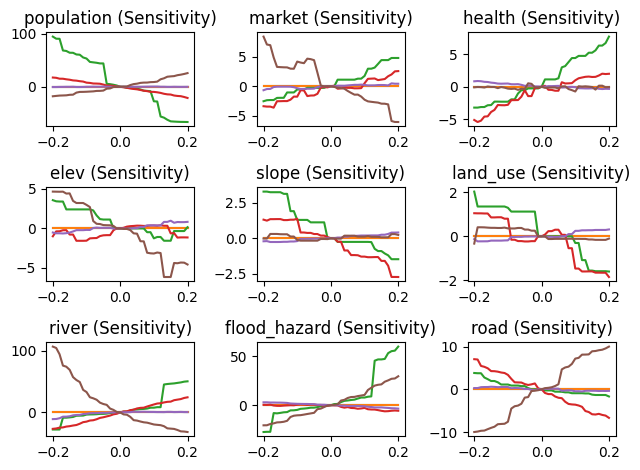

In [21]:
# df_km2[[x for x in df_km2.columns if str(x).endswith("_%")]].plot()
# plt.show()

def plotCritSensitivity(df: pd.DataFrame, criterion: list[str]):

    rows = 3
    cols = 3

    fig, axes = plt.subplots(nrows=rows, ncols=cols)

    coords = [[x, y] for x in range(rows) for y in range(cols)]

    target_columns = [x for x in df.columns if str(x).endswith("_%")]
    for crit, [x, y] in zip(criterion, coords):
        t_df = df[df['name'] == crit]
        x_axis = t_df.index.values

        for t_col in target_columns:
            y_axis = t_df[t_col].values
            axes[x, y].plot(x_axis, y_axis)

        axes[x, y].set_title(f"{crit} (Sensitivity)")

    plt.tight_layout()
    plt.show()


plotCritSensitivity(df_km2, list(crit_idx.values()))

In [22]:
df_km2.to_csv("sensitive_analysis.csv")